# Arabic Cyberbullying Detection Using Deep Learning

This project applies deep learning models to detect cyberbullying in Arabic tweets using the ArbCyD dataset. The project includes data exploration, preprocessing, model training, model comparison, and final evaluation.

## Part 1: Loading and Inspecting the Dataset

In this part, I load the Arabic cyberbullying dataset and inspect its structure. This step is important because it helps me understand the columns, the labels, and whether the data has any missing values before starting preprocessing and deep learning modeling.

In [1]:
import pandas as pd
import numpy as np

#loading the dataset
url = "https://raw.githubusercontent.com/Hassan-zeidan/AAI612_Zeidan_Deep_learning/main/Week%208/Final%20project/ArbCyD%20Dataset.csv"
df = pd.read_csv(url)

#showing basic informations

print("Dataset shape: ", df.shape)
print("\nColumn names: ")
print(df.columns)

print("\nThe first 5 rows: ")
print(df.head())

print("\nData types: ")
print(df.dtypes)

print("\nMissing values: ")
print(df.isnull().sum())

Dataset shape:  (10000, 3)

Column names: 
Index(['Tweets', 'Domain', 'Label'], dtype='object')

The first 5 rows: 
                                              Tweets  Domain         Label
0   لعلمكم فقط ان نزل لها نسخه مع انها ما فازت بذ...  Gaming  Non-bullying
1              واضح يوبي سوفت تبي تخربها ماتبي تعقل   Gaming  Non-bullying
2                                 اكثر يوتيبر محترم   Gaming  Non-bullying
3   نفس الحجة يستخدمونها على موضوع يقولون شوفوا إ...  Gaming  Non-bullying
4   واضح انه مدفوع لك، ولا عندك كرامه صدق ان لم ت...  Gaming      bullying

Data types: 
Tweets    object
Domain    object
Label     object
dtype: object

Missing values: 
Tweets    0
Domain    0
Label     0
dtype: int64


## Part 2: Exploring the Target Labels

In this part, I check the class labels in the dataset and count how many examples belong to each class. This is important because it helps me understand whether the dataset is balanced and whether the model may face difficulty learning one class more than the other.

In [2]:
#checking the unique labels
print("unique labels: ")
print(df['Label'].unique())

#counting how many rows belong to each label
print("\nlabel counts : ")
print(df["Label"].value_counts())

unique labels: 
['Non-bullying' 'bullying']

label counts : 
Label
Non-bullying    6204
bullying        3796
Name: count, dtype: int64


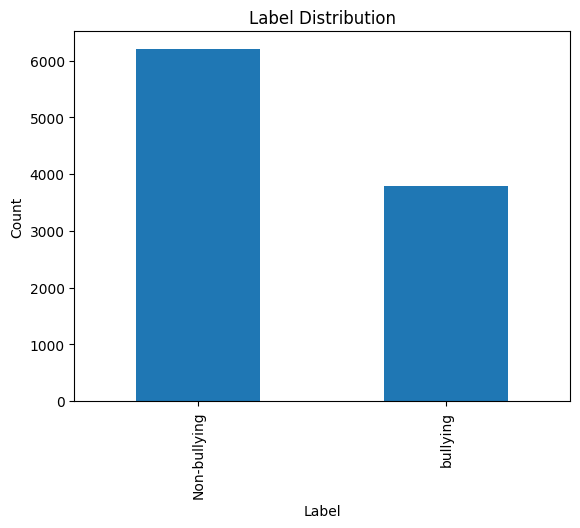

In [3]:
import matplotlib.pyplot as plt

# plotting the label distribution
df["Label"].value_counts().plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

## Part 3: Exploring Tweet Length

In this part, I analyze the length of the tweets in the dataset. This helps me understand how short or long the Arabic text samples are before tokenization and padding. It is also useful later when choosing the maximum sequence length for the deep learning model.

In [4]:
#creating a new column for tweet length
df["tweet_length"]=df["Tweets"].astype(str).apply(len)

#Showing basic statistics
print("Tweet length statistics: ")
print(df["tweet_length"].describe())

print("\nShortest tweet length:", df["tweet_length"].min())
print("Longest tweet length:", df["tweet_length"].max())
print("Average tweet length:", df["tweet_length"].mean())

Tweet length statistics: 
count    10000.000000
mean       121.365900
std         71.490477
min          6.000000
25%         62.000000
50%        107.000000
75%        178.000000
max        281.000000
Name: tweet_length, dtype: float64

Shortest tweet length: 6
Longest tweet length: 281
Average tweet length: 121.3659


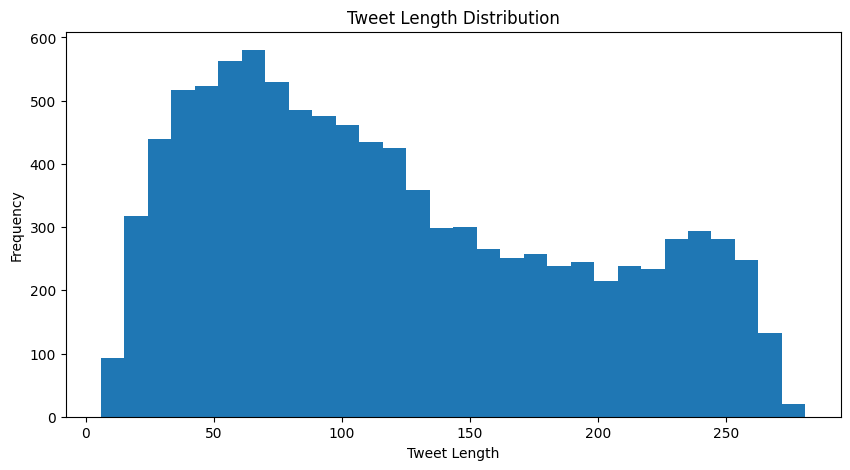

In [5]:
import matplotlib.pyplot as plt

# plotting the tweet length distribution
plt.figure(figsize=(10, 5))
plt.hist(df["tweet_length"], bins=30)
plt.title("Tweet Length Distribution")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")
plt.show()

<Figure size 800x500 with 0 Axes>

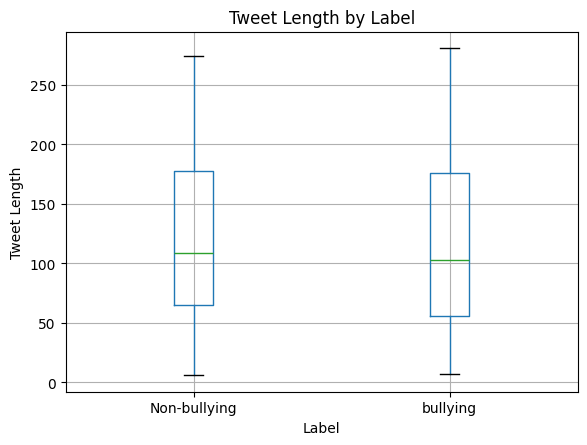

In [6]:
# comparing tweet length by label
plt.figure(figsize=(8, 5))
df.boxplot(column="tweet_length", by="Label")
plt.title("Tweet Length by Label")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Tweet Length")
plt.show()

## Part 4: Encoding the Labels

In this part, I convert the target labels into numeric values so they can be used by the deep learning model. Since this is a binary classification problem, I encode non-bullying as 0 and bullying as 1.

In [7]:
# converting text labels into numeric labels
df["label_encoded"] = df["Label"].map({"Non-bullying": 0,"bullying": 1})

# checking the first few rows
print(df[["Label", "label_encoded"]].head())

# checking the encoded label counts
print("\nEncoded label counts:")
print(df["label_encoded"].value_counts())

# checking if there are any missing encoded labels
print("\nMissing values in encoded labels:")
print(df["label_encoded"].isnull().sum())

          Label  label_encoded
0  Non-bullying              0
1  Non-bullying              0
2  Non-bullying              0
3  Non-bullying              0
4      bullying              1

Encoded label counts:
label_encoded
0    6204
1    3796
Name: count, dtype: int64

Missing values in encoded labels:
0


## Part 5: Splitting the Dataset

In this part, I separate the tweet texts from the target labels and split the dataset into training, validation, and test sets. I use stratified splitting so that the bullying and non-bullying classes keep nearly the same distribution in each subset.

In [8]:
from sklearn.model_selection import train_test_split

#defining X and y
X = df["Tweets"]
y = df["label_encoded"]

#first split: training set and temporary set
X_train, X_temp , y_train, y_temp = train_test_split(X,y,test_size=0.30,random_state=42,stratify=y)

#second split: validation and test from the temporary set
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.5, random_state=42, stratify=y_temp)

# checking the shapes
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)


X_train shape: (7000,)
X_val shape: (1500,)
X_test shape: (1500,)

y_train shape: (7000,)
y_val shape: (1500,)
y_test shape: (1500,)


In [9]:
# checking label distribution after splitting
print("Training label distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation label distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))

Training label distribution:
label_encoded
0    0.620429
1    0.379571
Name: proportion, dtype: float64

Validation label distribution:
label_encoded
0    0.62
1    0.38
Name: proportion, dtype: float64

Test label distribution:
label_encoded
0    0.620667
1    0.379333
Name: proportion, dtype: float64


## Part 6: Tokenization and Padding

In this part, I convert the Arabic tweets into sequences of integers using tokenization. Then I apply padding so that all sequences have the same length before they are given to the deep learning model. I fit the tokenizer only on the training data to keep the process clean and avoid data leakage.

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# setting some basic values
max_words = 10000
max_len = 30

# creating the tokenizer
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")

# fitting only on training text
tokenizer.fit_on_texts(X_train)

# converting text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# applying padding
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

# checking shapes
print("X_train_pad shape:", X_train_pad.shape)
print("X_val_pad shape:", X_val_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

X_train_pad shape: (7000, 30)
X_val_pad shape: (1500, 30)
X_test_pad shape: (1500, 30)


In [11]:
# checking a sample tweet before and after tokenization
print("Original tweet:")
print(X_train.iloc[0])

print("\nSequence form:")
print(X_train_seq[0])

print("\nPadded form:")
print(X_train_pad[0])

Original tweet:
 مبروك للاتحاد نتيجه مستحقة 

Sequence form:
[85, 1449, 4593, 1]

Padded form:
[  85 1449 4593    1    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


## Part 7: Building the First Deep Learning Model

In this part, I build my first deep learning model for Arabic cyberbullying detection. The model starts with an embedding layer to learn word representations, followed by an LSTM layer to capture sequence patterns in the tweets, and finally a sigmoid output layer for binary classification.

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout

# setting vocabulary size
vocab_size = 10000

# building the model
model = Sequential()

model.add(Input(shape=(max_len,)))
model.add(Embedding(input_dim=vocab_size, output_dim=64))
model.add(LSTM(64))
model.add(Dropout(0.3))
model.add(Dense(1, activation="sigmoid"))

# compiling the model
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# showing the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

## Part 8: Training the LSTM Model

In this part, I train the LSTM model on the padded training data and evaluate it on the validation set during training. I use early stopping to reduce overfitting and stop the training process when the validation loss no longer improves.

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

# early stopping
early_stop = EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True)

# training the model
history = model.fit(X_train_pad,y_train,epochs=10,batch_size=32,validation_data=(X_val_pad, y_val),callbacks=[early_stop],verbose=1)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.6240 - loss: 0.6689 - val_accuracy: 0.7020 - val_loss: 0.5972
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.7990 - loss: 0.4509 - val_accuracy: 0.7567 - val_loss: 0.4873
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9112 - loss: 0.2352 - val_accuracy: 0.7600 - val_loss: 0.5308
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9576 - loss: 0.1107 - val_accuracy: 0.7793 - val_loss: 0.6584
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9769 - loss: 0.0678 - val_accuracy: 0.7440 - val_loss: 0.8571


The LSTM model learned quickly during the first two epochs and achieved its best validation loss at epoch 2. After that, training accuracy continued to increase, but validation loss started to worsen, which suggests overfitting. Early stopping helped control this issue by stopping the training process and restoring the best model weights.

## Part 9: Visualizing Training Performance

In this part, I plot the training and validation accuracy and loss across epochs. These graphs help me understand how the model learned over time and whether overfitting started to appear during training.

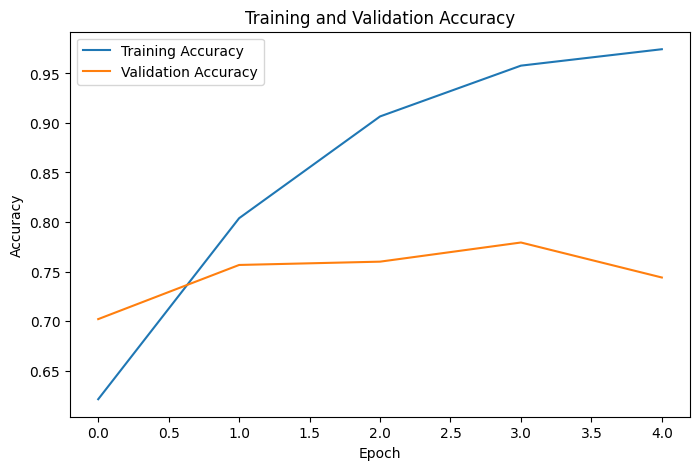

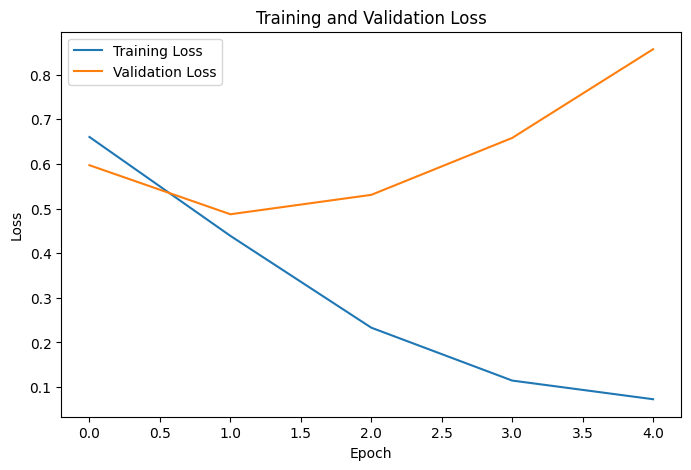

In [14]:
import matplotlib.pyplot as plt

# plotting accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# plotting loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Part 10: Evaluating the Model on the Test Set

In this part, I evaluate the trained LSTM model on the test set. This gives a more realistic measure of how well the model performs on unseen Arabic tweets.

In [15]:
# evaluating the model on the test set
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7546 - loss: 0.4971
Test loss: 0.468475878238678
Test accuracy: 0.765999972820282


## Part 11: Detailed Evaluation with Predictions, Confusion Matrix, and Classification Report

In this part, I generate predictions on the test set and evaluate the model using a confusion matrix and a classification report. This gives a deeper understanding of model performance beyond accuracy, especially for the bullying and non-bullying classes separately.

In [16]:
from sklearn.metrics import confusion_matrix, classification_report

# getting prediction probabilities
y_pred_prob = model.predict(X_test_pad)

# converting probabilities into class labels
y_pred = (y_pred_prob > 0.5).astype("int32")

# flattening the predictions so they match y_test shape
y_pred = y_pred.flatten()

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Confusion Matrix:
[[800 131]
 [220 349]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.86      0.82       931
           1       0.73      0.61      0.67       569

    accuracy                           0.77      1500
   macro avg       0.76      0.74      0.74      1500
weighted avg       0.76      0.77      0.76      1500



The baseline LSTM model achieved an accuracy of around 76% on the test set. It performed well on the non-bullying class, with high recall and a strong F1-score. However, performance on the bullying class was weaker, especially in recall, which means the model missed many actual bullying tweets. This suggests that while the model learned useful patterns, it was still biased toward predicting the non-bullying class more often.

## Part 12: Improving the Model with Class Weights

The baseline LSTM model showed weaker recall for the bullying class, which means it missed many actual bullying tweets. To address this issue, I retrain the same model using class weights so that the minority class receives more importance during training.

In [17]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# computing class weights
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = {0: weights[0], 1: weights[1]}

print("Class weights:")
print(class_weights)

Class weights:
{0: np.float64(0.8058945429426664), 1: np.float64(1.3172751223184043)}


In [18]:
# building the improved model
model_weighted = Sequential()

model_weighted.add(Input(shape=(max_len,)))
model_weighted.add(Embedding(input_dim=vocab_size, output_dim=64))
model_weighted.add(LSTM(64))
model_weighted.add(Dropout(0.3))
model_weighted.add(Dense(1, activation="sigmoid"))

# compiling the model
model_weighted.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# training the weighted model
history_weighted = model_weighted.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.5978 - loss: 0.6793 - val_accuracy: 0.6840 - val_loss: 0.6114
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8147 - loss: 0.4288 - val_accuracy: 0.7660 - val_loss: 0.4874
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9134 - loss: 0.2338 - val_accuracy: 0.7727 - val_loss: 0.6097
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9599 - loss: 0.1259 - val_accuracy: 0.7560 - val_loss: 0.7279
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9690 - loss: 0.0811 - val_accuracy: 0.7573 - val_loss: 0.8368


In [19]:
# evaluating the weighted model on the test set
test_loss_weighted, test_accuracy_weighted = model_weighted.evaluate(X_test_pad, y_test, verbose=1)

print("Weighted model test loss:", test_loss_weighted)
print("Weighted model test accuracy:", test_accuracy_weighted)

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7468 - loss: 0.5029
Weighted model test loss: 0.46851152181625366
Weighted model test accuracy: 0.7706666588783264


In [20]:
from sklearn.metrics import confusion_matrix, classification_report

# prediction probabilities from the weighted model
y_pred_prob_weighted = model_weighted.predict(X_test_pad)

# converting probabilities into class labels
y_pred_weighted = (y_pred_prob_weighted > 0.5).astype("int32").flatten()

# confusion matrix
cm_weighted = confusion_matrix(y_test, y_pred_weighted)
print("Weighted Model Confusion Matrix:")
print(cm_weighted)

print("\nWeighted Model Classification Report:")
print(classification_report(y_test, y_pred_weighted))

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Weighted Model Confusion Matrix:
[[762 169]
 [175 394]]

Weighted Model Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.82      0.82       931
           1       0.70      0.69      0.70       569

    accuracy                           0.77      1500
   macro avg       0.76      0.76      0.76      1500
weighted avg       0.77      0.77      0.77      1500



## Part 13 Result: Comparing the Baseline and Weighted Models

The weighted LSTM model improved the detection of bullying tweets compared with the baseline LSTM model. Although the baseline LSTM achieved a similar overall accuracy, its recall for the bullying class was lower, which means it missed more actual bullying tweets. After using class weights, the weighted LSTM gave better bullying recall and a stronger bullying F1-score, while also achieving the highest overall test accuracy in the final comparison.

This result shows that handling class imbalance was important in this project. The weighted LSTM model paid more attention to the bullying class and produced a better balance between general performance and harmful tweet detection. For this reason, it was considered stronger than the baseline LSTM and was later selected as the final model after comparing it with the weighted GRU.

## Part 14: Trying a GRU Model with Class Weights

In this part, I build a GRU-based deep learning model and train it using the same class weights used in the weighted LSTM model. This helps me compare LSTM and GRU fairly and decide which recurrent architecture works better for Arabic cyberbullying detection.

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# building the GRU model
model_gru = Sequential()

model_gru.add(Input(shape=(max_len,)))
model_gru.add(Embedding(input_dim=vocab_size, output_dim=64))
model_gru.add(GRU(64))
model_gru.add(Dropout(0.3))
model_gru.add(Dense(1, activation="sigmoid"))

# compiling the model
model_gru.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# showing the summary
model_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 30, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665,025 (2.54 MB)

 Trainable params: 665,025 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# early stopping
early_stop = EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True)

# training the weighted GRU model
history_gru = model_gru.fit(X_train_pad,y_train,epochs=10,batch_size=32,validation_data=(X_val_pad, y_val),callbacks=[early_stop],class_weight=class_weights,verbose=1)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.5043 - loss: 0.6918 - val_accuracy: 0.6153 - val_loss: 0.6855
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.5457 - loss: 0.6909 - val_accuracy: 0.6313 - val_loss: 0.6636
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.7409 - loss: 0.5323 - val_accuracy: 0.7713 - val_loss: 0.4981
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9197 - loss: 0.2056 - val_accuracy: 0.7627 - val_loss: 0.5871
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.9660 - loss: 0.0924 - val_accuracy: 0.7573 - val_loss: 0.6714
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9835 - loss: 0.0459 - val_accuracy: 0.7667 - val_loss: 0.8627


## Part 15: Tuning the GRU Model

The first GRU model showed strong validation performance, but it also started to overfit after a few epochs. To reduce overfitting, I try a small tuning change by increasing the dropout rate from 0.3 to 0.5 while keeping the rest of the model the same.

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# building the tuned GRU model
model_gru_tuned = Sequential()

model_gru_tuned.add(Input(shape=(max_len,)))
model_gru_tuned.add(Embedding(input_dim=vocab_size, output_dim=64))
model_gru_tuned.add(GRU(64))
model_gru_tuned.add(Dropout(0.5))
model_gru_tuned.add(Dense(1, activation="sigmoid"))

# compiling the model
model_gru_tuned.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# training the tuned GRU model
history_gru_tuned = model_gru_tuned.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.4750 - loss: 0.6947 - val_accuracy: 0.5907 - val_loss: 0.6916
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.5563 - loss: 0.6782 - val_accuracy: 0.5993 - val_loss: 0.6470
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8251 - loss: 0.4037 - val_accuracy: 0.7713 - val_loss: 0.4749
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.9374 - loss: 0.1717 - val_accuracy: 0.7513 - val_loss: 0.6227
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.9730 - loss: 0.0774 - val_accuracy: 0.7907 - val_loss: 0.6245
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.9872 - loss: 0.0453 - val_accuracy: 0.7800 - val_loss: 0.7940


## Part 16: Evaluating the Weighted GRU Model

In this part, I evaluate the original GRU model with class weights on the test set. This allows me to compare it fairly with the baseline LSTM and the weighted LSTM and decide which model performs best for Arabic cyberbullying detection.

In [24]:
# evaluating the original weighted GRU model on the test set
test_loss_gru, test_accuracy_gru = model_gru.evaluate(X_test_pad, y_test, verbose=1)

print("GRU model test loss:", test_loss_gru)
print("GRU model test accuracy:", test_accuracy_gru)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7565 - loss: 0.5196
GRU model test loss: 0.4929652512073517
GRU model test accuracy: 0.7620000243186951


In [25]:
from sklearn.metrics import confusion_matrix, classification_report

# prediction probabilities from the GRU model
y_pred_prob_gru = model_gru.predict(X_test_pad)

# converting probabilities into class labels
y_pred_gru = (y_pred_prob_gru > 0.5).astype("int32").flatten()

# confusion matrix
cm_gru = confusion_matrix(y_test, y_pred_gru)
print("GRU Model Confusion Matrix:")
print(cm_gru)

print("\nGRU Model Classification Report:")
print(classification_report(y_test, y_pred_gru))

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
GRU Model Confusion Matrix:
[[821 110]
 [247 322]]

GRU Model Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       931
           1       0.75      0.57      0.64       569

    accuracy                           0.76      1500
   macro avg       0.76      0.72      0.73      1500
weighted avg       0.76      0.76      0.75      1500



## Part 17: Comparing All Models

In this part, I summarize the results of all tested models in one comparison table. This makes it easier to compare their overall accuracy and their performance on the bullying class, especially recall and F1-score.

In [28]:
results_df = pd.DataFrame({"Model": ["Baseline LSTM", "Weighted LSTM", "Weighted GRU"],
                           "Test Accuracy": [0.7660, 0.7707, 0.7620],
                           "Bullying Precision": [0.73, 0.70, 0.75],
                           "Bullying Recall": [0.61, 0.69, 0.57],
                           "Bullying F1-score": [0.67, 0.70, 0.64]})

print(results_df)

           Model  Test Accuracy  Bullying Precision  Bullying Recall  \
0  Baseline LSTM         0.7660                0.73             0.61   
1  Weighted LSTM         0.7707                0.70             0.69   
2   Weighted GRU         0.7620                0.75             0.57   

   Bullying F1-score  
0               0.67  
1               0.70  
2               0.64  


In [29]:
results_df

,Model,Test Accuracy,Bullying Precision,Bullying Recall,Bullying F1-score
0,Baseline LSTM,0.7660,0.73,0.61,0.67
1,Weighted LSTM,0.7707,0.70,0.69,0.70
2,Weighted GRU,0.7620,0.75,0.57,0.64


## Part 18: Final Model Selection and Interpretation

Based on the comparison table, the weighted LSTM model was selected as the final model for this project. Although all three models achieved similar overall accuracy, the weighted LSTM gave the best balance between general performance and bullying detection in the final results. It achieved the highest test accuracy among the tested models and also produced the strongest bullying recall and F1-score. This means it was better at identifying harmful tweets than the baseline LSTM and the weighted GRU. Since the main objective of the project is to detect cyberbullying effectively, the weighted LSTM was considered the most suitable final model.

## Part 19: Conclusion

In this project, I built a deep learning system for Arabic cyberbullying detection using the ArbCyD dataset. I started by exploring the dataset, analyzing the label distribution, and examining tweet lengths. Then I prepared the data by encoding the labels, splitting the dataset, and converting the Arabic text into padded numerical sequences using tokenization.

After preprocessing, I trained and compared three deep learning models: a baseline LSTM, a weighted LSTM, and a weighted GRU. The results showed that the baseline LSTM achieved reasonable overall accuracy but had weaker recall for the bullying class. Using class weights improved bullying detection, and the weighted LSTM achieved the best overall performance among the tested models. It produced the highest test accuracy and the strongest bullying recall and F1-score, making it the most suitable final model for this task.

Overall, this project showed that recurrent deep learning models can be effective for Arabic cyberbullying detection, especially when class imbalance is handled carefully. A possible future improvement would be to try pretrained Arabic transformer models or further tune the LSTM or GRU architecture to improve performance even more.